# 05d — Anger × Delegitimisation rate per topic

Scatter plot: x = mean anger score, y = delegitimisation rate.  
Each dot = one **Manual Topic Label**; coloured by **Manual Cluster Label**.  
Data: `emotion_mainstream_resultsv3.csv` merged with topic assignments.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/Users/gretawette/Documents/Thesis")

df = pd.read_csv(ROOT / "04_SentimentAnalysis/outputs/emotion_mainstream_resultsv3.csv")
df.columns = df.columns.str.strip()

topics = pd.read_csv(ROOT / "02_TopicModeling/outputs/03_new_topic_assignments.csv")
topics["Manual Cluster Label"] = topics["Manual Cluster Label"].str.rstrip("#").str.strip()
topics["source"] = topics["source"].replace({"RT": "RT_de", "Tichys Einblick": "Tichys_Einblick"})

df = df.merge(
    topics[["row_id", "Manual Topic Label", "Manual Cluster Label"]].drop_duplicates("row_id"),
    on="row_id", how="left"
)

# Drop IRRELEVANT; keep NEUTRAL and framing rows
df = df[df["category"] != "IRRELEVANT"].copy()
df["emotion_anger"] = pd.to_numeric(df["emotion_anger"], errors="coerce")
print(f"Rows: {len(df):,}  |  Topics assigned: {df['Manual Topic Label'].notna().sum():,}")


Rows: 11,666  |  Topics assigned: 11,288


In [2]:
# ── Per-topic aggregation ─────────────────────────────────────────────────────
MIN_N = 10   # minimum hits per topic to include

df_t = df.dropna(subset=["Manual Topic Label"]).copy()

agg = df_t.groupby(["Manual Topic Label", "Manual Cluster Label"]).agg(
    anger   = ("emotion_anger", "mean"),
    n_total = ("category",      "count"),
    n_frame = ("category",      lambda x: (x != "NEUTRAL").sum()),
).reset_index()

agg["deleg_rate"] = agg["n_frame"] / agg["n_total"] * 100
agg = agg[agg["n_total"] >= MIN_N].copy()
print(f"Topics kept (n >= {MIN_N}): {len(agg)}")
agg.sort_values("deleg_rate", ascending=False).head(10)


Topics kept (n >= 10): 72


,Manual Topic Label,Manual Cluster Label,anger,n_total,n_frame,deleg_rate
21,Corruption Journalism,Media & Information Ecosystem,0.833947,312,222,71.153846
13,Charlie Kirk Incident,US & Transatlantic Politics,0.850181,197,131,66.497462
46,Journalism Broadcasters,Media & Information Ecosystem,0.804951,118,78,66.101695
55,Radio Format Metadata,Miscellaneous,0.767577,62,38,61.290323
51,NYC Mayoral Election,US & Transatlantic Politics,0.794916,20,11,55.000000
15,Christianity Religion,Miscellaneous,0.790223,97,52,53.608247
71,Wolfram Weimer Media,Media & Information Ecosystem,0.814956,345,179,51.884058
10,Books and Authors,Miscellaneous,0.780629,154,77,50.000000
35,"German TV, Talk Shows & ÖRR Criticism",Media & Information Ecosystem,0.872627,269,133,49.442379
37,Green Politics & Woke Culture#,Identity & Culture War,0.838874,112,54,48.214286


/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_14414/4082371542.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap     = plt.cm.get_cmap("tab20", len(clusters))


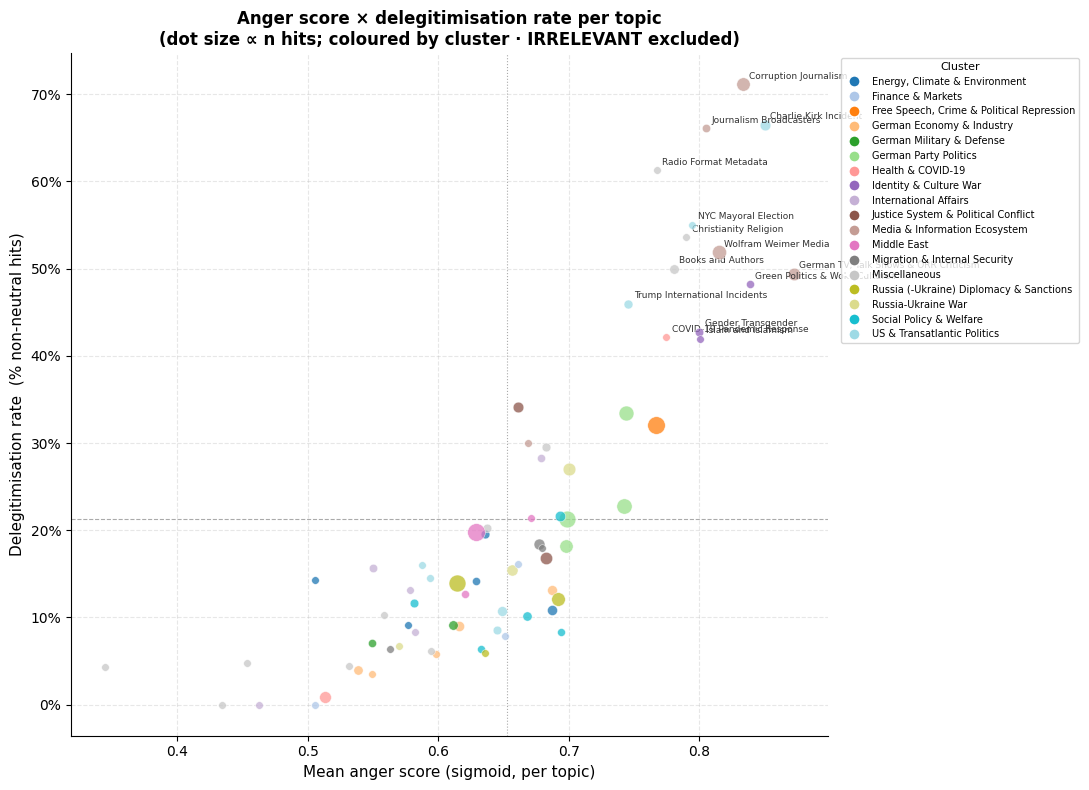

In [3]:
# ── Scatter plot: anger score × delegitimisation rate per topic ───────────────
clusters = sorted(agg["Manual Cluster Label"].dropna().unique())
cmap     = plt.cm.get_cmap("tab20", len(clusters))
c_color  = {cl: cmap(i) for i, cl in enumerate(clusters)}

fig, ax = plt.subplots(figsize=(11, 8))

for _, row in agg.iterrows():
    color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
    ax.scatter(row["anger"], row["deleg_rate"],
               color=color, s=max(30, row["n_total"] * 0.3),
               alpha=0.75, edgecolors="white", linewidths=0.4, zorder=3)
    # Label only topics with high framing or high anger
    if row["deleg_rate"] > 40 or row["anger"] > agg["anger"].quantile(0.9):
        ax.annotate(
            row["Manual Topic Label"],
            xy=(row["anger"], row["deleg_rate"]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=6.5, color="#333333",
        )

# Macro-mean reference lines
ax.axhline(agg["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle="--", label=f"Mean deleg. rate ({agg['deleg_rate'].mean():.1f}%)")
ax.axvline(agg["anger"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle=":", label=f"Mean anger ({agg['anger'].mean():.3f})")

ax.set_xlabel("Mean anger score (sigmoid, per topic)", fontsize=11)
ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title(
    "Anger score × delegitimisation rate per topic\n"
    "(dot size ∝ n hits; coloured by cluster · IRRELEVANT excluded)",
    fontsize=12, fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Cluster legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c_color[cl],
                  markersize=8, label=cl) for cl in clusters if cl in c_color]
ax.legend(handles=handles, title="Cluster", fontsize=7, title_fontsize=8,
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

plt.tight_layout()
plt.savefig(ROOT / "04_SentimentAnalysis/outputs/figures/05d_anger_vs_deleg_per_topic.png",
            dpi=150, bbox_inches="tight")
plt.show()


In [4]:
# ── Per-topic aggregation for FEAR ───────────────────────────────────────────
agg_fear = df.dropna(subset=["Manual Topic Label"]).groupby(
    ["Manual Topic Label", "Manual Cluster Label"]
).agg(
    fear    = ("emotion_fear", "mean"),
    n_total = ("category",     "count"),
    n_frame = ("category",     lambda x: (x != "NEUTRAL").sum()),
).reset_index()

agg_fear["emotion_fear"] = pd.to_numeric(agg_fear["fear"], errors="coerce")
agg_fear["deleg_rate"]   = agg_fear["n_frame"] / agg_fear["n_total"] * 100
agg_fear = agg_fear[agg_fear["n_total"] >= MIN_N].copy()
print(f"Topics kept (n >= {MIN_N}): {len(agg_fear)}")


Topics kept (n >= 10): 72


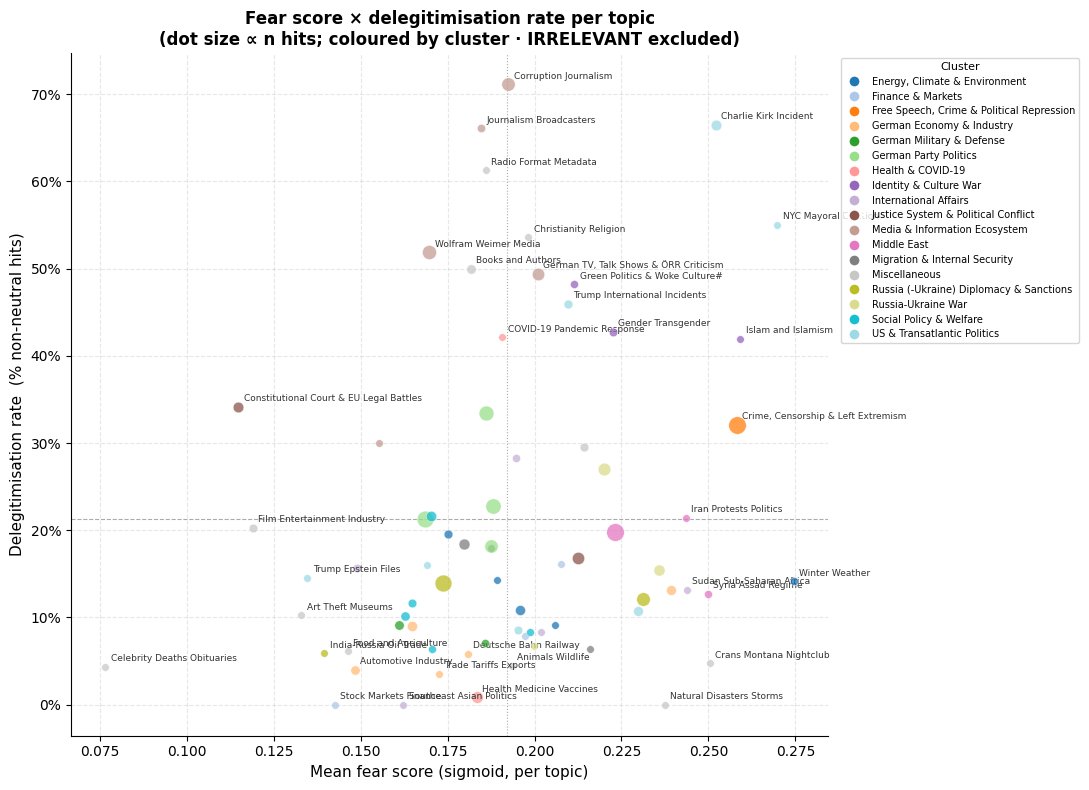

In [5]:
# ── Scatter plot: fear score × delegitimisation rate per topic ────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for _, row in agg_fear.iterrows():
    color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
    ax.scatter(row["emotion_fear"], row["deleg_rate"],
               color=color, s=max(30, row["n_total"] * 0.3),
               alpha=0.75, edgecolors="white", linewidths=0.4, zorder=3)
    high_deleg = row["deleg_rate"] > agg_fear["deleg_rate"].quantile(0.80)
    low_deleg  = row["deleg_rate"] < agg_fear["deleg_rate"].quantile(0.15)
    high_fear  = row["emotion_fear"] > agg_fear["emotion_fear"].quantile(0.88)
    low_fear   = row["emotion_fear"] < agg_fear["emotion_fear"].quantile(0.12)
    if high_deleg or low_deleg or high_fear or low_fear:
        ax.annotate(
            row["Manual Topic Label"],
            xy=(row["emotion_fear"], row["deleg_rate"]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=6.5, color="#333333",
        )

ax.axhline(agg_fear["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle="--", label=f"Mean deleg. rate ({agg_fear['deleg_rate'].mean():.1f}%)")
ax.axvline(agg_fear["emotion_fear"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle=":", label=f"Mean fear ({agg_fear['emotion_fear'].mean():.3f})")

ax.set_xlabel("Mean fear score (sigmoid, per topic)", fontsize=11)
ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title(
    "Fear score × delegitimisation rate per topic\n"
    "(dot size ∝ n hits; coloured by cluster · IRRELEVANT excluded)",
    fontsize=12, fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c_color[cl],
                  markersize=8, label=cl) for cl in clusters if cl in c_color]
ax.legend(handles=handles, title="Cluster", fontsize=7, title_fontsize=8,
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

plt.tight_layout()

plt.show()


In [6]:
from scipy.stats import pearsonr, spearmanr

for label, scores, deleg in [
    ("Anger",  agg["anger"],            agg["deleg_rate"]),
    ("Fear",   agg_fear["emotion_fear"], agg_fear["deleg_rate"]),
]:
    r_p, p_p = pearsonr(scores.dropna(),  deleg[scores.notna()])
    r_s, p_s = spearmanr(scores.dropna(), deleg[scores.notna()])
    print(f"{label}:")
    print(f"  Pearson  r = {r_p:.3f},  p = {p_p:.4f}")
    print(f"  Spearman ρ = {r_s:.3f},  p = {p_s:.4f}")
    print()

Anger:
  Pearson  r = 0.840,  p = 0.0000
  Spearman ρ = 0.853,  p = 0.0000

Fear:
  Pearson  r = 0.220,  p = 0.0635
  Spearman ρ = 0.232,  p = 0.0498



## Cluster-level view

Same scatter logic, but aggregated to **Manual Cluster Label** (one dot = one cluster).

In [7]:
# ── Per-cluster aggregation ──────────────────────────────────────────────────
MIN_N_CLUSTER = 30  # minimum hits per cluster to include

df["emotion_fear"] = pd.to_numeric(df["emotion_fear"], errors="coerce")

agg_cluster = (
    df.dropna(subset=["Manual Cluster Label"])
      .groupby("Manual Cluster Label")
      .agg(
          anger   = ("emotion_anger", "mean"),
          fear    = ("emotion_fear",  "mean"),
          n_total = ("category",      "count"),
          n_frame = ("category",      lambda x: (x != "NEUTRAL").sum()),
      )
      .reset_index()
)

agg_cluster["deleg_rate"] = agg_cluster["n_frame"] / agg_cluster["n_total"] * 100
agg_cluster = agg_cluster[agg_cluster["n_total"] >= MIN_N_CLUSTER].copy()
print(f"Clusters kept (n >= {MIN_N_CLUSTER}): {len(agg_cluster)}")
agg_cluster.sort_values("deleg_rate", ascending=False)

Clusters kept (n >= 30): 18


,Manual Cluster Label,anger,fear,n_total,n_frame,deleg_rate
10,Media & Information Ecosystem,0.828248,0.185083,1084,624,57.564576
7,Identity & Culture War,0.813913,0.227913,317,141,44.479495
2,"Free Speech, Crime & Political Repression",0.767038,0.258160,533,171,32.082552
17,US & Transatlantic Politics,0.705823,0.210938,810,258,31.851852
13,Miscellaneous,0.639316,0.173889,955,253,26.492147
9,Justice System & Political Conflict,0.673489,0.170694,458,111,24.235808
5,German Party Politics,0.720583,0.181467,1579,379,24.002533
15,Russia-Ukraine War,0.664016,0.222708,580,114,19.655172
11,Middle East,0.633261,0.229640,749,142,18.958611
8,International Affairs,0.590500,0.188023,376,64,17.021277


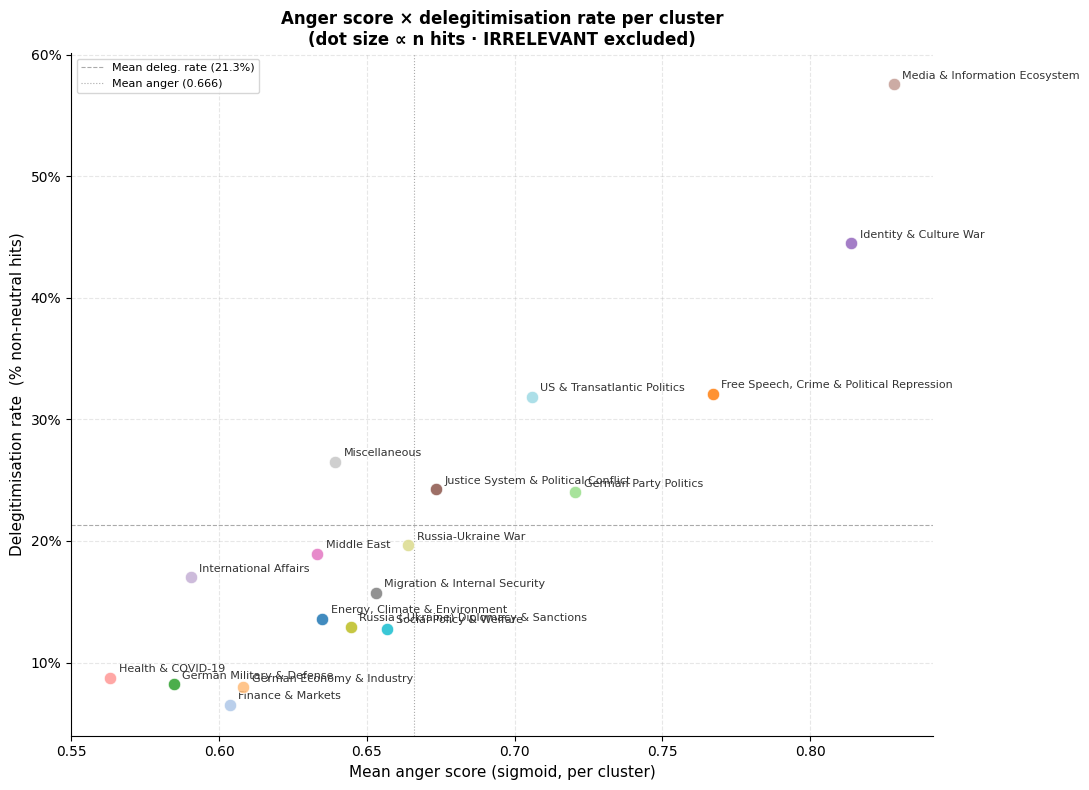

In [8]:
# ── Scatter plot: anger × delegitimisation rate per cluster ──────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for _, row in agg_cluster.iterrows():
    color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
    ax.scatter(row["anger"], row["deleg_rate"],
               color=color, s=max(80, row["n_total"] * 0.05),
               alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)
    ax.annotate(
        row["Manual Cluster Label"],
        xy=(row["anger"], row["deleg_rate"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=8, color="#333333",
    )

ax.axhline(agg_cluster["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle="--", label=f"Mean deleg. rate ({agg_cluster['deleg_rate'].mean():.1f}%)")
ax.axvline(agg_cluster["anger"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle=":", label=f"Mean anger ({agg_cluster['anger'].mean():.3f})")

ax.set_xlabel("Mean anger score (sigmoid, per cluster)", fontsize=11)
ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title(
    "Anger score × delegitimisation rate per cluster\n"
    "(dot size ∝ n hits · IRRELEVANT excluded)",
    fontsize=12, fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "04_SentimentAnalysis/outputs/figures/05d_anger_vs_deleg_per_cluster.png",
            dpi=150, bbox_inches="tight")
plt.show()

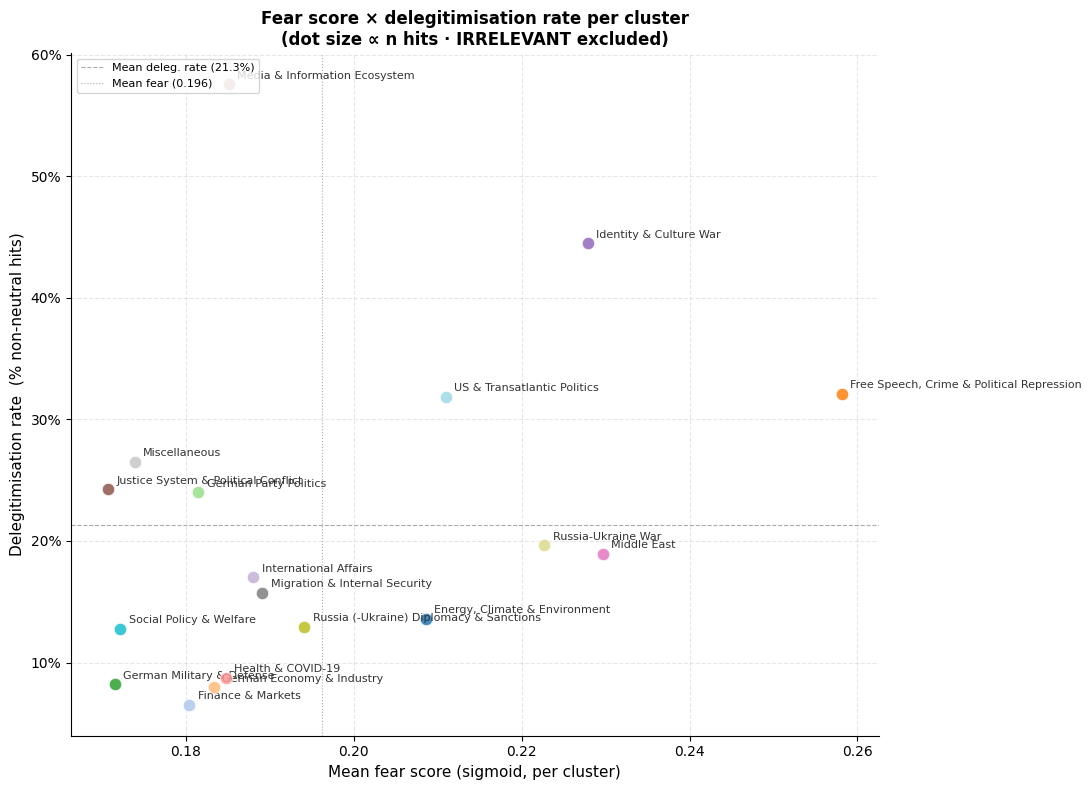

In [9]:
# ── Scatter plot: fear × delegitimisation rate per cluster ───────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for _, row in agg_cluster.iterrows():
    color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
    ax.scatter(row["fear"], row["deleg_rate"],
               color=color, s=max(80, row["n_total"] * 0.05),
               alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)
    ax.annotate(
        row["Manual Cluster Label"],
        xy=(row["fear"], row["deleg_rate"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=8, color="#333333",
    )

ax.axhline(agg_cluster["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle="--", label=f"Mean deleg. rate ({agg_cluster['deleg_rate'].mean():.1f}%)")
ax.axvline(agg_cluster["fear"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle=":", label=f"Mean fear ({agg_cluster['fear'].mean():.3f})")

ax.set_xlabel("Mean fear score (sigmoid, per cluster)", fontsize=11)
ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title(
    "Fear score × delegitimisation rate per cluster\n"
    "(dot size ∝ n hits · IRRELEVANT excluded)",
    fontsize=12, fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "04_SentimentAnalysis/outputs/figures/05d_fear_vs_deleg_per_cluster.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Cluster-level correlations ───────────────────────────────────────────────
for label, scores in [("Anger", agg_cluster["anger"]),
                      ("Fear",  agg_cluster["fear"])]:
    deleg = agg_cluster["deleg_rate"]
    mask  = scores.notna() & deleg.notna()
    r_p, p_p = pearsonr(scores[mask],  deleg[mask])
    r_s, p_s = spearmanr(scores[mask], deleg[mask])
    print(f"{label} (cluster level, n = {mask.sum()}):")
    print(f"  Pearson  r = {r_p:.3f},  p = {p_p:.4f}")
    print(f"  Spearman ρ = {r_s:.3f},  p = {p_s:.4f}")
    print()

Anger (cluster level, n = 18):
  Pearson  r = 0.916,  p = 0.0000
  Spearman ρ = 0.818,  p = 0.0000

Fear (cluster level, n = 18):
  Pearson  r = 0.330,  p = 0.1806
  Spearman ρ = 0.406,  p = 0.0950



## Combined view

Topics shown as faint grey dots in the background (no labels); clusters overlaid as coloured dots with labels.

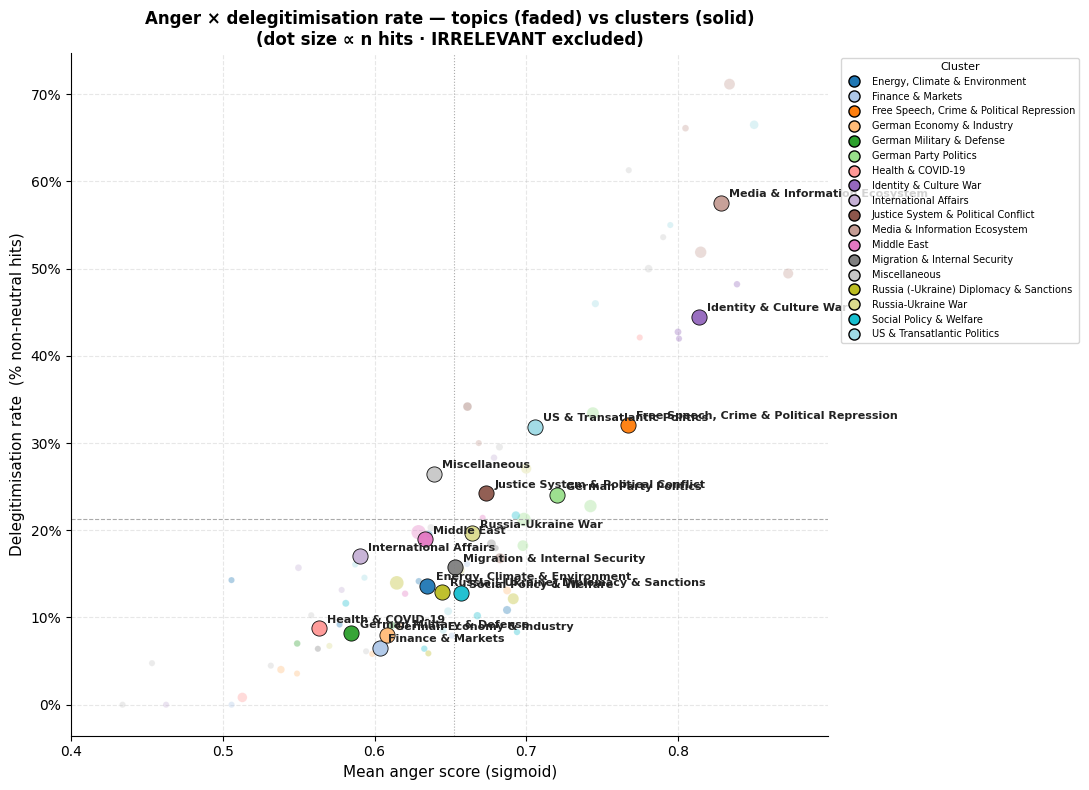

In [11]:
# ── Combined: anger × delegitimisation rate (topics behind, clusters on top) ─
X_MIN_ANGER = 0.4

fig, ax = plt.subplots(figsize=(11, 8))

# Background: topic dots, coloured by their cluster (no labels, faded)
topic_colors = [c_color.get(cl, "#aaaaaa") for cl in agg["Manual Cluster Label"]]
ax.scatter(
    agg["anger"], agg["deleg_rate"],
    s=np.maximum(20, agg["n_total"] * 0.2),
    c=topic_colors, alpha=0.35,
    edgecolors="white", linewidths=0.3,
    zorder=2,
)

# Foreground: cluster dots (coloured, with labels)
for _, row in agg_cluster.iterrows():
    color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
    ax.scatter(row["anger"], row["deleg_rate"],
               color=color, s=max(120, row["n_total"] * 0.05),
               alpha=0.95, edgecolors="black", linewidths=0.6, zorder=4)
    ax.annotate(
        row["Manual Cluster Label"],
        xy=(row["anger"], row["deleg_rate"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=8, color="#222222", fontweight="bold", zorder=5,
    )

# Reference lines based on the topic-level distribution (more granular)
ax.axhline(agg["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle="--", label=f"Mean deleg. rate ({agg['deleg_rate'].mean():.1f}%)")
ax.axvline(agg["anger"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle=":", label=f"Mean anger ({agg['anger'].mean():.3f})")

ax.set_xlim(left=X_MIN_ANGER)

ax.set_xlabel("Mean anger score (sigmoid)", fontsize=11)
ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title(
    "Anger × delegitimisation rate — topics (faded) vs clusters (solid)\n"
    "(dot size ∝ n hits · IRRELEVANT excluded)",
    fontsize=12, fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D
cluster_handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c_color[cl],
                          markeredgecolor="black", markersize=8, label=cl)
                   for cl in clusters if cl in c_color]
ax.legend(handles=cluster_handles, title="Cluster",
          fontsize=7, title_fontsize=8,
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

plt.tight_layout()
plt.savefig(ROOT / "04_SentimentAnalysis/outputs/figures/05d_anger_vs_deleg_combined.png",
            dpi=150, bbox_inches="tight")
plt.show()

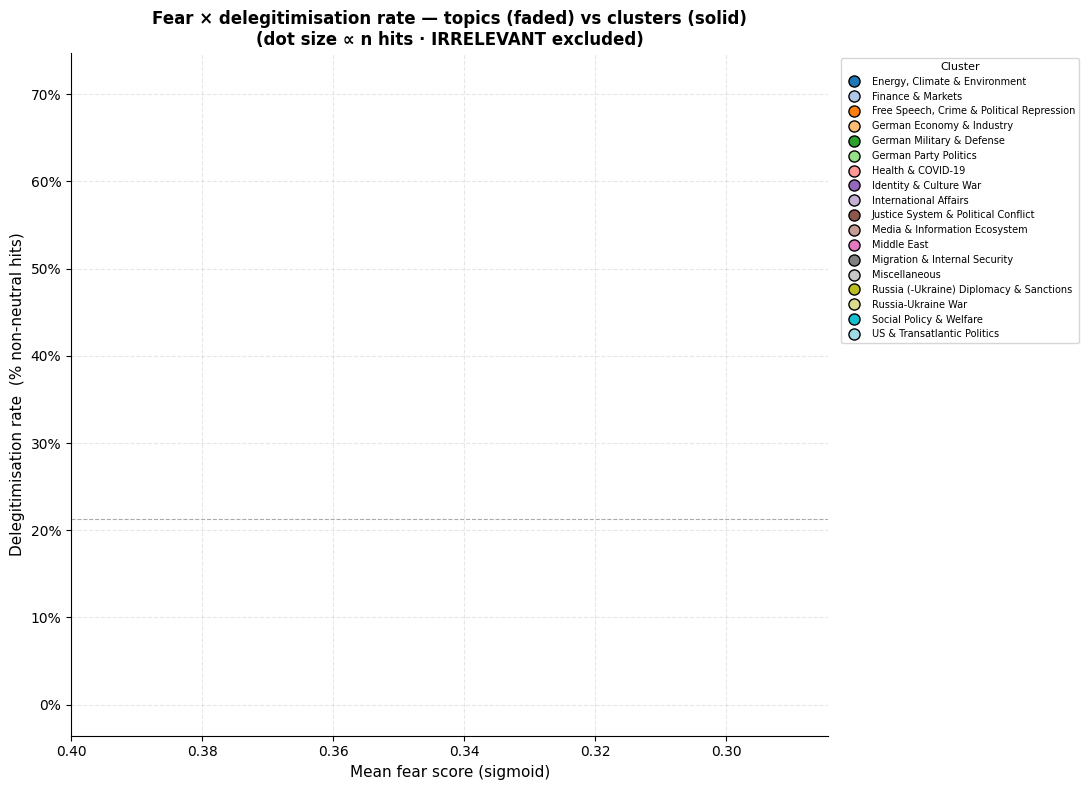

In [12]:
# ── Combined: fear × delegitimisation rate (topics behind, clusters on top) ─
X_MIN_FEAR = 0.4

fig, ax = plt.subplots(figsize=(11, 8))

# Background: topic dots, coloured by their cluster (no labels, faded)
topic_colors_f = [c_color.get(cl, "#aaaaaa") for cl in agg_fear["Manual Cluster Label"]]
ax.scatter(
    agg_fear["emotion_fear"], agg_fear["deleg_rate"],
    s=np.maximum(20, agg_fear["n_total"] * 0.2),
    c=topic_colors_f, alpha=0.35,
    edgecolors="white", linewidths=0.3,
    zorder=2,
)

# Foreground: cluster dots (coloured, with labels)
for _, row in agg_cluster.iterrows():
    color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
    ax.scatter(row["fear"], row["deleg_rate"],
               color=color, s=max(120, row["n_total"] * 0.05),
               alpha=0.95, edgecolors="black", linewidths=0.6, zorder=4)
    ax.annotate(
        row["Manual Cluster Label"],
        xy=(row["fear"], row["deleg_rate"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=8, color="#222222", fontweight="bold", zorder=5,
    )

ax.axhline(agg_fear["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle="--", label=f"Mean deleg. rate ({agg_fear['deleg_rate'].mean():.1f}%)")
ax.axvline(agg_fear["emotion_fear"].mean(), color="#aaaaaa", linewidth=0.8,
           linestyle=":", label=f"Mean fear ({agg_fear['emotion_fear'].mean():.3f})")

ax.set_xlim(left=X_MIN_FEAR)

ax.set_xlabel("Mean fear score (sigmoid)", fontsize=11)
ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title(
    "Fear × delegitimisation rate — topics (faded) vs clusters (solid)\n"
    "(dot size ∝ n hits · IRRELEVANT excluded)",
    fontsize=12, fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

cluster_handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c_color[cl],
                          markeredgecolor="black", markersize=8, label=cl)
                   for cl in clusters if cl in c_color]
ax.legend(handles=cluster_handles, title="Cluster",
          fontsize=7, title_fontsize=8,
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

plt.tight_layout()
plt.savefig(ROOT / "04_SentimentAnalysis/outputs/figures/05d_fear_vs_deleg_combined.png",
            dpi=150, bbox_inches="tight")
plt.show()